In [1]:
import pandas as pd
from pathlib import Path
import csv

# Path to the folder with genre CSVs
DATA_DIR = Path.cwd().parent / "data" / "raw" / "datasets" / "rajugc" / "imdb-movies-dataset-based-on-genre" / "versions" / "3"

print(f"Reading from: {DATA_DIR}")

dfs = []
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    print(f"Processing {csv_path.name}...")
    try:
        # Use standard csv module to bypass pandas/numpy conversion bugs
        with open(csv_path, mode="r", encoding="utf-8", errors="replace") as f:
            reader = csv.DictReader(f)
            rows = list(reader)
        if rows:
            dfs.append(pd.DataFrame.from_records(rows))
    except Exception as e:
        print(f"Error reading {csv_path.name}: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
    # Drop duplicates (same movie can appear in multiple genre files)
    df = df.drop_duplicates(subset=["movie_id"], keep="first").reset_index(drop=True)
    print(f"Shape after merge: {df.shape}")
else:
    print("No dataframes were loaded.")

df.head()


Reading from: /Users/neecat/Desktop/Projects/movie-recommender/data/raw/datasets/rajugc/imdb-movies-dataset-based-on-genre/versions/3
Processing action.csv...
Processing adventure.csv...
Processing animation.csv...
Processing biography.csv...
Processing crime.csv...
Processing family.csv...
Processing fantasy.csv...
Processing film-noir.csv...
Processing history.csv...
Processing horror.csv...
Processing mystery.csv...
Processing romance.csv...
Processing scifi.csv...
Processing sports.csv...
Processing thriller.csv...
Processing war.csv...
Shape after merge: (243197, 14)


,movie_id,movie_name,year,certificate,runtime,genre,rating,description,director,director_id,star,star_id,votes,gross(in $)
0,tt9114286,Black Panther: Wakanda Forever,2022,PG-13,161 min,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...,Ryan Coogler,/name/nm3363032/,"Letitia Wright, \nLupita Nyong'o, \nDanai Guri...","/name/nm4004793/,/name/nm2143282/,/name/nm1775...",204835.0,
1,tt1630029,Avatar: The Way of Water,2022,PG-13,192 min,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...,James Cameron,/name/nm0000116/,"Sam Worthington, \nZoe Saldana, \nSigourney We...","/name/nm0941777/,/name/nm0757855/,/name/nm0000...",295119.0,
2,tt5884796,Plane,2023,R,107 min,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...,Jean-François Richet,/name/nm0724938/,"Gerard Butler, \nMike Colter, \nTony Goldwyn, ...","/name/nm0124930/,/name/nm1591496/,/name/nm0001...",26220.0,
3,tt6710474,Everything Everywhere All at Once,2022,R,139 min,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...,"Dan Kwan, \nDaniel Scheinert",/name/nm3453283/,"Michelle Yeoh, \nStephanie Hsu, \nJamie Lee Cu...","/name/nm3215397/,/name/nm0000706/,/name/nm3513...",327858.0,
4,tt5433140,Fast X,2023,,,"Action, Crime, Mystery",,Dom Toretto and his family are targeted by the...,Louis Leterrier,/name/nm0504642/,"Vin Diesel, \nJordana Brewster, \nTyrese Gibso...","/name/nm0004874/,/name/nm0108287/,/name/nm0879...",,


In [2]:
# Pre-processing
df = df.copy()

# Rename gross column if it exists
if "gross(in $)" in df.columns:
    df = df.rename(columns={"gross(in $)": "gross"})

# Normalize string columns (strip whitespace/newlines)
for col in ["movie_name", "certificate", "genre", "description", "director", "director_id", "star", "star_id"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("\n", " ", regex=False)
            .str.replace("  +", " ", regex=True)
            .str.strip()
        )

# Parse runtime to numeric (minutes); e.g. "161 min" -> 161
def parse_runtime(x):
    if pd.isna(x) or x == "" or x == "None":
        return pd.NA
    s = str(x).replace(" min", "").strip()
    return pd.to_numeric(s, errors="coerce")

if "runtime" in df.columns:
    df["runtime_min"] = df["runtime"].apply(parse_runtime)
    df = df.drop(columns=["runtime"])

# Explicitly convert to numeric types
for col in ["year", "rating", "votes", "gross", "runtime_min"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with no rating (needed for recommendations)
if "rating" in df.columns:
    df = df.dropna(subset=["rating"]).reset_index(drop=True)

print(f"Shape after preprocessing: {df.shape}")
print(df.dtypes)
df.head()


Shape after preprocessing: (138690, 14)
movie_id           str
movie_name         str
year           float64
certificate        str
genre              str
rating         float64
description        str
director           str
director_id        str
star               str
star_id            str
votes          float64
gross          float64
runtime_min    float64
dtype: object


,movie_id,movie_name,year,certificate,genre,rating,description,director,director_id,star,star_id,votes,gross,runtime_min
0,tt9114286,Black Panther: Wakanda Forever,2022.0,PG-13,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...,Ryan Coogler,/name/nm3363032/,"Letitia Wright, Lupita Nyong'o, Danai Gurira, ...","/name/nm4004793/,/name/nm2143282/,/name/nm1775...",204835.0,NaN,161.0
1,tt1630029,Avatar: The Way of Water,2022.0,PG-13,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...,James Cameron,/name/nm0000116/,"Sam Worthington, Zoe Saldana, Sigourney Weaver...","/name/nm0941777/,/name/nm0757855/,/name/nm0000...",295119.0,NaN,192.0
2,tt5884796,Plane,2023.0,R,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...,Jean-François Richet,/name/nm0724938/,"Gerard Butler, Mike Colter, Tony Goldwyn, Yoso...","/name/nm0124930/,/name/nm1591496/,/name/nm0001...",26220.0,NaN,107.0
3,tt6710474,Everything Everywhere All at Once,2022.0,R,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...,"Dan Kwan, Daniel Scheinert",/name/nm3453283/,"Michelle Yeoh, Stephanie Hsu, Jamie Lee Curtis...","/name/nm3215397/,/name/nm0000706/,/name/nm3513...",327858.0,NaN,139.0
4,tt10954600,Ant-Man and the Wasp: Quantumania,2023.0,PG-13,"Action, Adventure, Comedy",6.6,"Scott Lang and Hope Van Dyne, along with Hank ...",Peyton Reed,/name/nm0715636/,"Paul Rudd, Evangeline Lilly, Jonathan Majors, ...","/name/nm0748620/,/name/nm1431940/,/name/nm3718...",5396.0,NaN,125.0


In [3]:
# Save processed data
from pathlib import Path

processed_dir = Path.cwd().parent / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / "movies_processed.csv"
df.to_csv(processed_path, index=False)
print(f"Saved processed data to: {processed_path}")

Saved processed data to: /Users/neecat/Desktop/Projects/movie-recommender/data/processed/movies_processed.csv


In [4]:
# Summary
print("Missing values:")
print(df.isna().sum())
if "rating" in df.columns:
    print("\nRating range:", df["rating"].min(), "-", df["rating"].max())
if "year" in df.columns:
    print("Years:", df["year"].min(), "-", df["year"].max())


Missing values:
movie_id            0
movie_name          0
year               17
certificate         0
genre               0
rating              0
description         0
director            0
director_id         0
star                0
star_id             0
votes               0
gross          126688
runtime_min     11410
dtype: int64

Rating range: 1.0 - 10.0
Years: 1894.0 - 2023.0


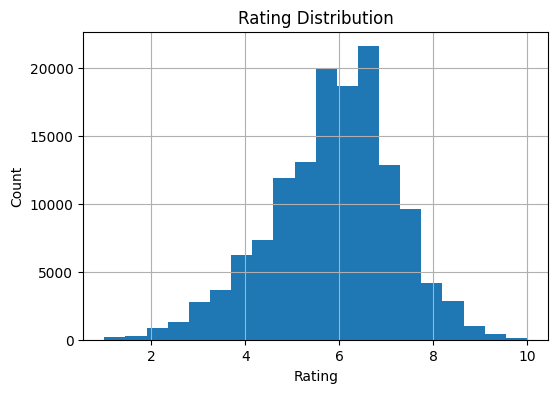

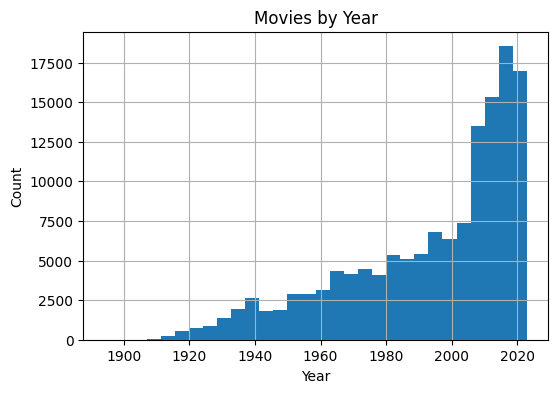

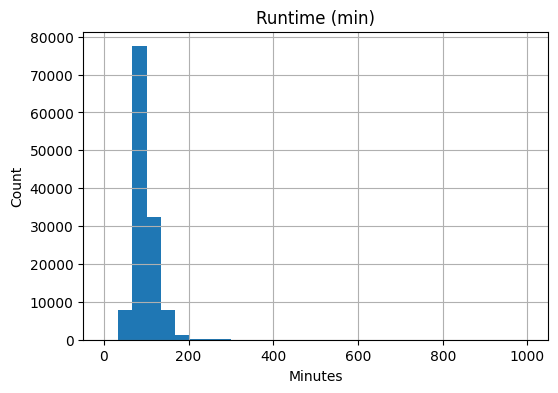

In [5]:
# EDA: basic distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["rating"].hist(bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
df["year"].dropna().astype(int).hist(bins=30)
plt.title("Movies by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
df["runtime_min"].dropna().hist(bins=30)
plt.title("Runtime (min)")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()


genre
Drama        64423
Comedy       33377
Romance      32013
Action       29412
Crime        24024
Thriller     23839
Horror       20333
Adventure    17070
Mystery      10755
Family       10367
Fantasy       8443
Sci-Fi        6716
War           5248
History       4926
Animation     4755
Name: count, dtype: int64


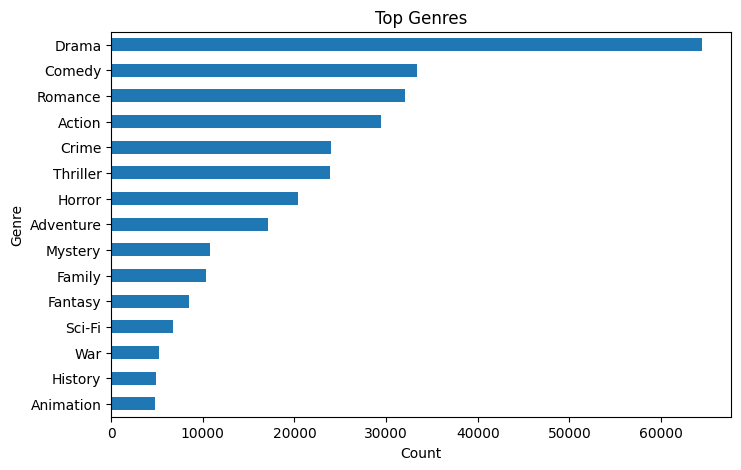

In [6]:
# EDA: top genres
# Split genre strings into list
genre_series = df["genre"].str.split(",").apply(lambda xs: [x.strip() for x in xs if x.strip()])

# Count genres
genre_counts = genre_series.explode().value_counts().head(15)
print(genre_counts)

plt.figure(figsize=(8, 5))
genre_counts.sort_values().plot(kind="barh")
plt.title("Top Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()
